# 🛍️ Customer Classification using K-Nearest Neighbors (KNN)

### ABTalksOnAI Challenge — Day 25

**Objective:** Classify customer order behavior (Completed / Cancelled) using KNN.

**Steps:**
- Data preprocessing & feature selection  
- Encode categorical variables  
- Feature scaling  
- Train KNN model  
- Tune K value & evaluate performance  

**Tools:** Python, Pandas, Scikit-learn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/aaronrao/Desktop/projects/Global Coding Challenge/day25/customer_dataset(in).csv")
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,3/20/2024,Standard
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,4/20/2024,Overnight
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,10/17/2023,Express
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,8/9/2024,Overnight
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,5/21/2024,Express


In [4]:
print(df['Order Status'].value_counts())

Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64


In [5]:
# Separate classes
completed_df = df[df['Order Status'] == 'Completed']
cancelled_df = df[df['Order Status'] == 'Cancelled']
completed_sample = completed_df.sample(n=6500, random_state=42)
cancelled_sample = cancelled_df.sample(n=6500, random_state=42)
df = pd.concat([completed_sample, cancelled_sample])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df['Order Status'].value_counts())

Order Status
Completed    6500
Cancelled    6500
Name: count, dtype: int64


In [6]:
df = df.drop(columns=['Customer ID', 'SKU', 'Purchase Date'])

In [7]:
df['Order Status'] = df['Order Status'].map({'Cancelled': 0, 'Completed': 1})

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop('Order Status', axis=1)
y = df['Order Status']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [13]:
y_pred = knn.predict(X_test_scaled)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.49653846153846154

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.50      0.50      1325
           1       0.49      0.49      0.49      1275

    accuracy                           0.50      2600
   macro avg       0.50      0.50      0.50      2600
weighted avg       0.50      0.50      0.50      2600



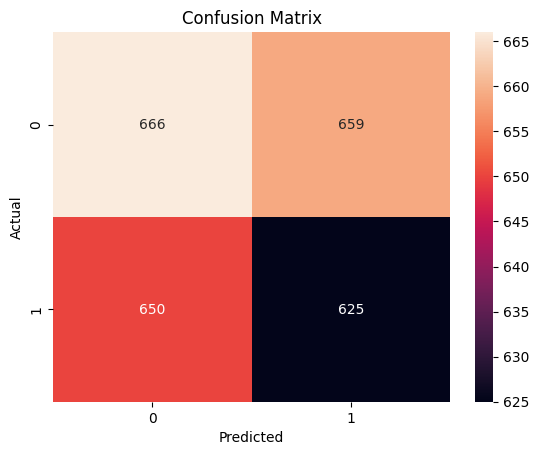

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

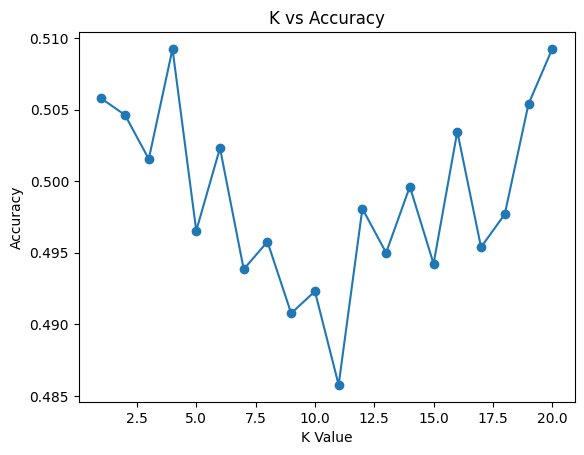

In [17]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

In [18]:
best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 4
Best Accuracy: 0.5092307692307693


In [19]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=4)

In [20]:
def predict_customer(input_data):
    input_df = pd.DataFrame([input_data])
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    input_scaled = scaler.transform(input_df)
    prediction = final_model.predict(input_scaled)
    return "Completed" if prediction[0] == 1 else "Cancelled"

In [21]:
sample_input = {
    'Age': 30,
    'Gender': 'Male',
    'Loyalty Member': 'Yes',
    'Product Type': 'Smartphone',
    'Rating': 4,
    'Payment Method': 'Credit Card',
    'Total Price': 2000,
    'Unit Price': 500,
    'Quantity': 4,
    'Shipping Type': 'Express'
}

print(predict_customer(sample_input))

Cancelled


In [23]:
file_path = "/Users/aaronrao/Desktop/projects/Global Coding Challenge/day25/balanced_customer_dataset.csv"
df.to_csv(file_path, index=False)
print("Balanced dataset saved at:", file_path)

Balanced dataset saved at: /Users/aaronrao/Desktop/projects/Global Coding Challenge/day25/balanced_customer_dataset.csv
